<a href="https://www.kaggle.com/code/stefancomanita/reinforcement-learning-intro-with-frozen-lake?scriptVersionId=284808320" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

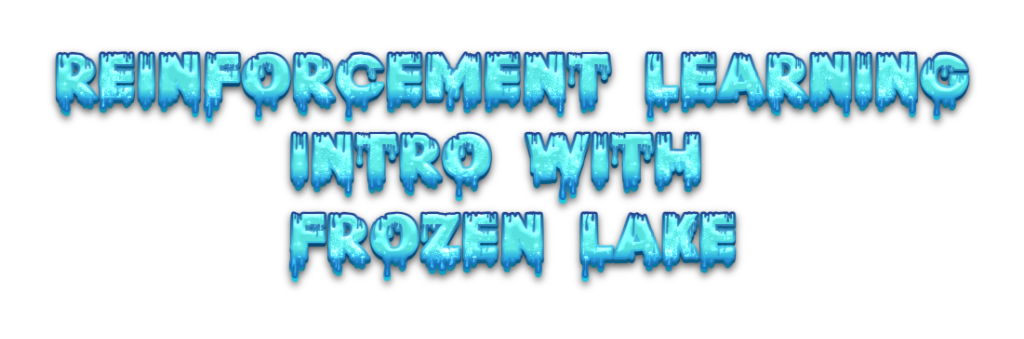

# Intro
In this tutorial our goal is to train an AI to solve the Frozen Lake environment using Reinforcemt Learning. We will achieve this by applying Q Learning and on the techical side we will use Python and the Gymnasium framework.

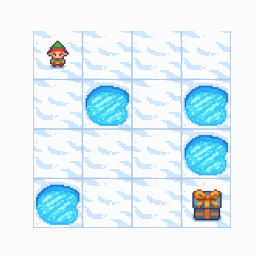

By the time you will have finished this tutorial you will be very familiar with Q Learning and Gymnasium. This knowledge will serve as a great stating point for applying reinforcement learning in other projects.

Reinforcement Learning is a topic of great interest with many real life aplications, training AIs must start from somewere, let's start toghether from here!

# What is Reinforcemtn Learning

Reinforcement learning (RL) is a type of machine learning where an agent learns to make a sequence of decisions by trying to maximize a reward it receives for its actions in an environment. It involves an agent, an environment, and a reward system, where the agent takes actions, and the environment responds with a new state and a reward or punishment.

RL has many applications, from self driving cars to robotics.

# The Gym/Gymnasium framework

Gym developed by OpenAI is a de-facto framework for building a target environment of reinforcement learning (RL)- based control and optimization. Gym has been unmaintained since 2022.

Gymnasium is a maintained fork of OpenAI’s Gym library. The Gymnasium interface is simple, pythonic, and capable of representing general RL problems


# Setting up the environment
We will use pip to instal the ToyText subset of Gymnasium, as this is the part we need sd it contains the Frozen Lake environment.

# Q Learning intro
Q-Learning is a reinforcement learning algorithm that helps an agent learn the best actions to take in an environment to maximize rewards through trial and error. It works by using a Q-table to store Q-values, which represent the expected future reward for taking a specific action in a given state. The agent iteratively updates this Q-table using feedback (rewards) from the environment and applies a strategy like the epsilon-greedy method to balance exploring new actions and exploiting known good actions. 

## Q Table
The agent will use a Q-table to take the best possible action based on the expected reward for each state in the environment. In simple words, a Q-table is a data structure of sets of actions and states, and we use the Q-learning algorithm to update the values in the table.

In the Frozen Lake enviorment we have a table of the size 16 by 4, this corelates to the observation space of 16 and the action space of 4. This means that at any point of our state we can make 4 actions.

## Q Value backpropagation
The algorithm will start by taking random actions, this is the exploration phase. After by pure chance we manage to get to the goal state we want to back propagate this information all the way back to the initial state.

## Q Value formula
We will use a formula to compute the new value for a Q Value in our Q Table

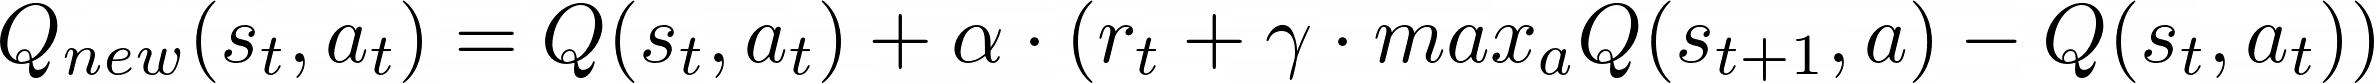

## Epsilon Greedy
Epsilon greedy is a reinforcement learning strategy that balances exploitation (choosing the best action we already know) and exploration (trying new actions). At each step, it chooses a random action with a small probability, epsilon (epsilon), and picks the best action based on current knowledge with a probability of 1-epsilon. 
This ensures that an agent doesn't get stuck doing suboptimal things by occasionally exploring new possibilities. 

In [1]:
!pip install gymnasium[ToyText]

In [2]:
import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
import time

from IPython.display import clear_output
from matplotlib import animation

# The FrozenLake enviorment

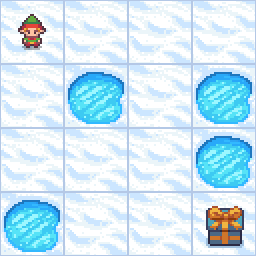

Frozen Lake involves a small elf that attempts crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake.

This environment is part of the Toy Text, Toy Text environments are designed to be extremely simple, with small discrete state and action spaces, and hence easy to learn. As a result, environments from Toy Text are a great starting point for beggining Reinforcement Learning.

## Observation Space and Action Space
The frozen lake has Observation Space of 16 and Action Space of 4 which means there are a total of 16 states (positions) we can find ourselfs in and in each of that position we can perform 4 actions.

In the Frozen Lake enviorment there are 16 positions, these are our observation stateas, meaning our agent can be in one of these 16 states.
And for each state we can perfome one of 4 actions: up, down, left or right. These are our action space.
Learning how to solve the Frozen Lake is like learning which action you should choose in every state. To know which action is the best in a given state, we would like to assign a quality value to our actions. We have 16 states and 4 actions, so want to calculate 16 x 4 = 64 values.

## Environment States
The states are numbered from 0 to 15, like in the image bellow
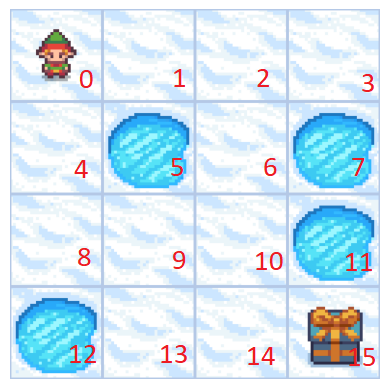

We can see that state zero is our startig state and 15 is our end state.
The goal of the environment is to move from state zero to state 15.
States 5, 7, 11, 12 are holes, if our agent/elf steps on them the games is finished with a loss.



A path we can take to solve the environment is the following:
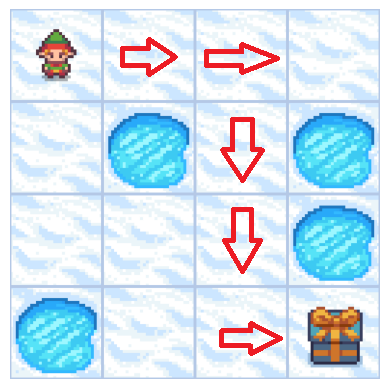
This is not the only path we can take to solve the environment but it's one of the few optima ones.

## Initiazing the Environment
In order to initialize our environment we must issue

`env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)`
Here we create an environment for the Frozen Lake, we set the render mode to rgb_array and set the is_slippery parameter to false.

## Rendering
The Frozen Lake environment can be rendered in a few modes, some of these are human, ansi and rgb_array. In this notebook we will use rgb_array as we will be able to disaply some really nice images and gif!

## Slippery
This parameter if set to true (which is the default) will make the steps unpredictable, meaning that if we issue a DOWN step it has just a 33% chance of DOWN being aplied, and LEFT or RIGHT each get a 33% chance of happening.

For this tutorial we will keep the is_slippery parameter to false.

## Performing Steps

To perform a step in the Frozen Lake environment we can issue the statement
`newState, reward, terminated, truncated, info = env.step(action)`

The actions are the following:
<div>
    <ul>
        <li>0: Move left</li>
        <li>1: Move down</li>
        <li>2: Move right</li>
        <li>3: Move up</li>
    </ul>
</div>

And we can see that the step function return a few interesting result for us.

### Reward Shaping
In the Frozen Lake environment all steps return the reward zero, except moving to the goal state, on state 16. We must backpropage this value in order to fill our table.

We print the reward in one of the code snippets bellow.

The reward shapping can be overriden in the Frozen Lake environment but we will not discuss this in this tutorial.

In [3]:
# small utility function to display a frame
def showFrame(frame):
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

/usr/local/lib/python3.11/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

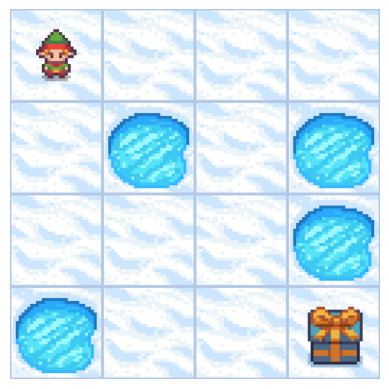

In [4]:
# here we declare out environment with the render mode and the slippery set to false
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)
env.reset()

showFrame(env.render())

reward for step is 0.0


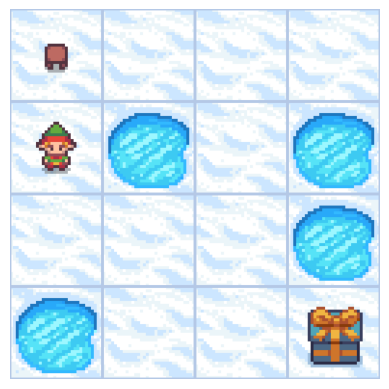

In [5]:
# perform the step down
newState, reward, _, _, _ = env.step(1)
# also print the reward
print(f"reward for step is {reward}")
showFrame(env.render())

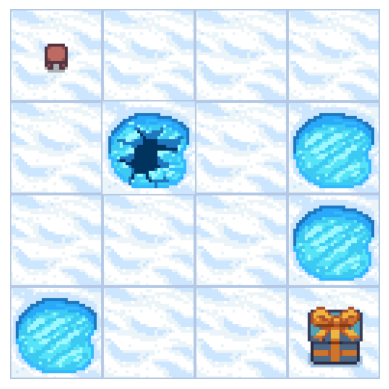

In [6]:
# perform the step right
env.step(2)
showFrame(env.render())

# Preparing the Q Table
Let's create our Q Table, this has the dimension of the observable space multiplied by the action space.

In [7]:
# define and print the empty q table
q = np.zeros((env.observation_space.n, env.action_space.n))
q

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

# Training the agent
In this next section we will train our agent, meaning we will populate the Q Table with the correct values.

In [8]:
    # hyperparameters
    episodes = 1200  # total number of episodes
    alpha = 0.5  # learning rate
    gamma = 0.9  # discount factor
    epsilon = 1.0  # amount of randomness in the action selection
    epsilon_decay = 0.001  # fixed amount to decrease

In [9]:
# we will use this list to store the outputs of each episode
outcomes = []

In [10]:
    for episode in range(episodes):

        state = env.reset()[0]

        outcomes.append(False)
        done = False

        while not done:
            random = np.random.random()

            if random < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q[state])

            newState, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated
            
            q[state][action] = q[state][action] + (alpha * (reward + gamma * np.max(q[newState]) - q[state][action]))

            state = newState

            if reward == 1:
                outcomes[-1] = True

        epsilon = max(epsilon - epsilon_decay, 0)
        env.close()

In [11]:
    # let us check how many of the episodes where successful
    successCount = outcomes.count(True)
    print(f"success count: {successCount}")

success count: 614


Cool, a little over 600 episodes hwre successful, meaning that we managed to find a path to the gift.

Now let's also plot the distribution of the episode outcomes.

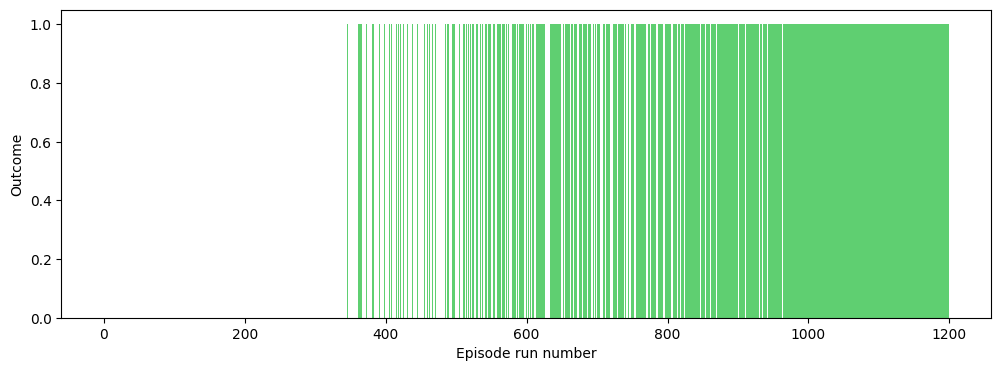

In [12]:
    # Plot training outcomes
    plt.figure(figsize=(12, 4))
    plt.xlabel("Episode run number")
    plt.ylabel("Outcome")
    plt.bar(range(len(outcomes)), outcomes, color="#5FCF71", width=1)
    plt.show()
    plt.close()

# Inspecting out trained Q Table
Let us take a look at our *Q Table*

In [13]:
q

array([[0.531441  , 0.59049   , 0.59049   , 0.531441  ],
       [0.53144066, 0.        , 0.6561    , 0.58564404],
       [0.50264471, 0.729     , 0.37267279, 0.54912866],
       [0.60237977, 0.        , 0.        , 0.        ],
       [0.59049   , 0.6561    , 0.        , 0.531441  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.81      , 0.        , 0.56738883],
       [0.        , 0.        , 0.        , 0.        ],
       [0.6561    , 0.        , 0.729     , 0.59049   ],
       [0.6561    , 0.81      , 0.81      , 0.        ],
       [0.729     , 0.9       , 0.        , 0.729     ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.78072986, 0.9       , 0.70575477],
       [0.81      , 0.9       , 1.        , 0.81      ],
       [0.        , 0.        , 0.        , 0.        ]])

Our *Q Table* looks really nice!
If we look at state at state 14 (counting from zero) which is the one next to last we can see the rewards from the action space
`[0.81      , 0.9       , 1.        , 0.81      ]`
Meaning if we are at tile/state 14 and we move right, position 2 from our action array we get the maximum reward, which is 1!
This makes sens as if we are at state 14 and we move to the right we get to the goal and we finish the episode with succes!

You can inspect the Q Table and see what the agent think it's the best action at each point.


# Using the trained agent
Now that we have a trainned agend let's put it to work!
But first let's declare an utility method to save some frames as a gif.

In [14]:
def saveFramesAsGif(frames, path='./', filename='animation.gif'):
    fps = 5
    dpi = 300
    interval = 500

    plt.figure(figsize=(frames[0].shape[1] / dpi, frames[0].shape[0] / dpi), dpi=dpi)
    patch = plt.imshow(frames[0])
    plt.axis('off')

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(plt.gcf(), animate, frames=len(frames), interval=interval)

    anim.save(path + filename, writer='imagemagick', fps=fps)
    plt.close()

In [15]:
    env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')

    # store all the steps talen as frames
    frames = []

    state = env.reset()[0]
    done = False
    frames.append(env.render())

    while not done:
        action = np.argmax(q[state])

        state, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())
        
        done = terminated or truncated

        if reward == 1:
            print("we have won the episode")
            break


    # save the episode as a gif
    saveFramesAsGif(frames)

error: XDG_RUNTIME_DIR not set in the environment.
MovieWriter imagemagick unavailable; using Pillow instead.


we have won the episode


Let's see a cool gif with the path our agent used, Excelent, this is a really great visual!
![Episode played by trained agent](animation.gif)

Excelent, so we just played a and episode with the trained agent and it managed to win on the first try. 

Also we can inspect the steps it took to win the game.

Now let us play a larger number of games and plot the outcomes.

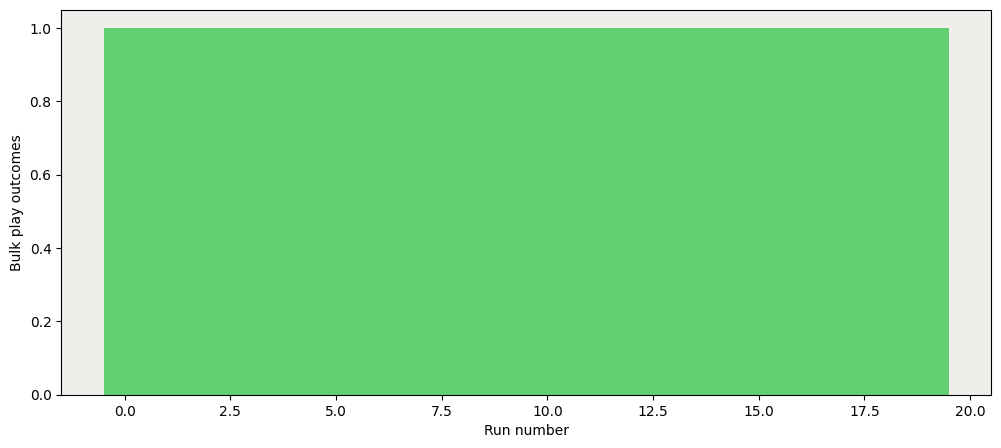

In [16]:
    env = gym.make('FrozenLake-v1', is_slippery=False)
    outcomes = []

    for episode in range(20):
        
        state = env.reset()[0]
        done = False

        outcomes.append(False)
    
        while not done:
            action = np.argmax(q[state])
    
            state, reward, terminated, truncated, _ = env.step(action)
                
            done = terminated or truncated
    
            if reward == 1:
                outcomes[-1] = True
                break


    plt.figure(figsize=(12, 5))
    plt.xlabel("Run number")
    plt.ylabel("Bulk play outcomes")
    ax = plt.gca()
    ax.set_facecolor('#efeeea')
    plt.bar(range(len(outcomes)), outcomes, color="#5FCF71", width=1.0)
    plt.show()
    plt.close()

We can see our agent managed to finish all the games succesfully, excelent!

# Concusions
Learning Reinforcement Learning is valuable for solving complex, sequential decision-making problems where traditional programming is difficult

In this tutorial we learned the basics of Reinforcement Learning, Q LEarning and Gym/Gymnasium.

This is a great starting point in a long jurney.

# Finish
You have made it to the end, thank you!